In [1]:
# ==== Imports ====

# essential libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# standard libraries
import os, tempfile
from pathlib import Path
from collections import OrderedDict
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple, Iterable, Set, Union




In [2]:
# ==== Device Selection ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# === MLP, EQL, FEATLIB ===

class Sin(nn.Module):
    def forward(self, input):
        return torch.sin(input)

class SimpleMLP(nn.Module):
    def __init__(self, n_layers, hidden_size):
        super(SimpleMLP, self).__init__()
        assert n_layers >= 2, "n_layers must be at least 2"

        layers = []
        # First layer: input (2,) -> hidden_size
        layers.append(nn.Linear(2, hidden_size))
        layers.append(Sin())

        # Hidden layers: (m -> m)
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(Sin())

        # Final layer: (m -> 1)
        layers.append(nn.Linear(hidden_size, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, t, x):
        input_tensor = torch.cat((t, x), dim=1)  # Concatenate along feature axis
        return self.model(input_tensor)
    
class symMLP(nn.Module):
    """
    Readout-only baseline, EQL-swappable contract.

    v(F) = readout([F])

    - Keeps readout shape (K -> 1), bias=False
    - Simple linear transformation of features acted on by optimizer (GD, Lasso, etc.)

    """
    def __init__(self, in_dim: int, prod_dim: int = 2, bias: bool = False):
        super().__init__()
        self.readout = nn.Linear(in_dim, 1, bias=False)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        Y = torch.cat([feats], dim=1)  # (N, K+1)
        return self.readout(Y)              # (N, 1)

# === Feature Library ===

@dataclass
class FeatureTensorOut:
    F: torch.Tensor                  # (B,K) normalized if normalize=True
    names: List[str]                 # length K
    scales: torch.Tensor             # (K,) detached; 1.0 if not normalized
    raw_cols: Optional[torch.Tensor] = None  # (B,K) raw (unnormalized) if keep_raw=True

class FeatureTensor:
    """
    Builds feature columns: "u", "u_x", "u_xx", ...
    Any requested non-primitive terms are ignored (with a warning).

    Expects u_out shape (B,1) and x tensor (B,1) with requires_grad=True
    when derivative terms are requested. Returns F shaped (B,K).
    """

    def __init__(
        self,
        terms: Iterable[str],
        normalize: bool = True,
        eps: float = 1e-12,
        keep_raw: bool = False,
    ) -> None:
        self.terms = list(terms)
        self.normalize = bool(normalize)
        self.eps = float(eps)
        self.keep_raw = bool(keep_raw)

        # runtime artifacts
        self.names: List[str] = []
        self.scales: Optional[torch.Tensor] = None

    def _l2_detached(self, col: torch.Tensor) -> torch.Tensor:
        # scalar (detached)
        return col.detach().reshape(-1).norm(p=2).clamp_min(self.eps)

    def _grad1(self, y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return torch.autograd.grad(
            y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
        )[0]

    def build(
        self,
        u_out: torch.Tensor,
        *,
        t: Optional[torch.Tensor] = None,
        x: Optional[torch.Tensor] = None,
        y: Optional[torch.Tensor] = None,
    ) -> FeatureTensorOut:
        _ = (t, y)  # explicit ignore (keeps signature stable)

        allowed = {"u", "u_x", "u_xx", "uu_x"}
        requested = [s for s in self.terms if s in allowed]
        ignored = [s for s in self.terms if s not in allowed]
        if ignored:
            print(f"Ignoring non-primitive terms: {ignored} [c:FeatureTensor]")

        if not requested:
            raise RuntimeError(f"No primitive features requested (allowed: {sorted(allowed)})")

        need = set(requested)

        feats: List[torch.Tensor] = []       # list of (B,1) normalized columns
        raw_list: List[torch.Tensor] = []    # list of (B,1) raw columns if keep_raw
        names: List[str] = []
        scales_list: List[torch.Tensor] = [] # list of scalar tensors (detached)

        def add(name: str, raw: torch.Tensor, normalize_col: bool = True) -> None:
            raw_ = raw[:, None] if raw.ndim == 1 else raw
            if raw_.ndim != 2 or raw_.shape[1] != 1:
                raise ValueError(f"Feature '{name}' must be (B,1); got {tuple(raw_.shape)}")

            if self.normalize and normalize_col:
                s = self._l2_detached(raw_)     # scalar
                col = raw_ / s
            else:
                s = torch.tensor(1.0, device=raw_.device, dtype=raw_.dtype)
                col = raw_

            feats.append(col)
            names.append(name)
            scales_list.append(s.detach())

            if self.keep_raw:
                raw_list.append(raw_)

        # Cache derivatives
        if ("u_x" in need or "u_xx" in need or "uu_x" in need) and x is None:
            raise ValueError("Requested x-derivative feature but x is None.")

        
        u_x = self._grad1(u_out, x)
        u_xx = self._grad1(u_x, x)
        uu_x = u_out * u_x

        self.u_raw = u_out
        self.ux_raw = u_x
        self.uxx_raw = u_xx
        self.uux_raw = uu_x
            
        # Build primitives
        if "u" in need:
            add("u", u_out, normalize_col=True)
        if "u_x" in need:
            add("u_x", u_x, normalize_col=True)
        if "u_xx" in need:
            add("u_xx", u_xx, normalize_col=True)
        if "uu_x" in need: 
            add("uu_x", uu_x, normalize_col=True)
        if not feats:
            raise RuntimeError("No features produced. Check 'terms' and provided coords.")

        F = torch.cat(feats, dim=1)  # (B,K)
        scales = torch.stack(scales_list).reshape(-1).detach()  # (K,)

        raw_cols = torch.cat(raw_list, dim=1) if self.keep_raw else None  # (B,K) or None

        # save artifacts and primitives for inspection
        self.scales = scales.detach()  # save scales for inspection (detached)

        return FeatureTensorOut(F=F, names=names, scales=scales, raw_cols=raw_cols)

# === EQL ===

class EQL(nn.Module):
    def __init__(self, in_dim, prod_dim=2, bias=False):
        """
        in_dim: number of input features (e.g. u, ux, uxx)

        prod_dim: number of linear combinations to create for pairwise products
        """
        super().__init__()
        self.linear = nn.Linear(in_dim, prod_dim, bias=bias)
        self.readout = nn.Linear(in_dim + 1, 1, bias=False)


    def forward(self, feats):
        Z = self.linear(feats)  # (N, prod_dim)
        self.preop_ns = Z  # save for inspection
        prod_neuron = torch.prod(Z, dim=1, keepdim=True)  # (N,1)
        self.postop_ns = prod_neuron  # save for inspection
        Y_layer = torch.cat([feats, prod_neuron], dim=1)        # (N, in_dim+1)
        self.Y = Y_layer  # save for inspection
        return self.readout(Y_layer)

        

In [4]:
# ==== PDE Extractor ====

def extract_symbolic_pde_deep(
    trainer,
    show_raw=True,
    show_physical=True,
    library_scales_attr=("feature_scales", "feature_powers"),  # you currently return "powers" but it is scales
    eps=1e-12
):
    """
    Extract effective linear map v(F) = w^T F where F is the library fed into v. 
    F includes constant term so bias is not needed in v net itself. 

    Supports current library normalization:
        F_i = raw_i / scale_i   where scale_i = ||raw_i|| (detached)
    Then:
        v(F) = Σ w_i * (raw_i / scale_i) + b
      => coeff on raw_i is w_raw_i = w_i / scale_i

    Input: 
    """

    # ---------- 1) Compose Linear stack ----------

    layers = trainer.v.model
    if isinstance(layers, nn.Module) and not hasattr(layers, "__iter__"):
        layers = [layers]

    W_eff = None
    for m in layers:
        if isinstance(m, nn.Linear):
            W = m.weight.detach().cpu()              # [out_dim, in_dim]
            if W_eff is None:
                W_eff = W.clone()
            else:
                W_eff = W @ W_eff
        elif isinstance(m, (nn.ReLU, nn.Tanh, nn.Sigmoid, nn.GELU, nn.SiLU, nn.LeakyReLU, nn.ELU)):
            raise ValueError("Nonlinear activation in v; linear coefficient extraction is invalid.")
        else:
            raise ValueError(f"Unhandled layer in v: {type(m).__name__}")

    if W_eff is None:
        raise ValueError("No nn.Linear layers found in trainer.v.model.")

    if W_eff.shape[0] != 1:
        raise ValueError(f"v outputs {W_eff.shape[0]} dims; expected 1.")

    w = W_eff.reshape(-1).numpy()                      # [n_features]

    names = getattr(trainer, "feature_names", [f"f{i}" for i in range(len(w))])

    # ---------- 3) Undo your library column normalization (raw features) ----------
    scales = None
    if library_scales_attr is not None:
        if isinstance(library_scales_attr, (tuple, list)):
            for attr in library_scales_attr:
                if hasattr(trainer, attr):
                    scales = getattr(trainer, attr)
                    if scales is not None:
                        break
        else:
            scales = getattr(trainer, library_scales_attr, None)
            print(f'library_scales_attr is {library_scales_attr}, scales is {scales}')

    if scales is not None:
        if torch.is_tensor(scales):
            s = scales.detach().cpu().numpy().reshape(-1)
        else:
            s = np.asarray(scales).reshape(-1)

        if len(s) != len(w):
            raise ValueError(f"Scale length {len(s)} != n_features {len(w)}")

        s = np.clip(s, eps, None)
        w_raw = w / s
    else:
        # Must make sure scales are provided in trainer
        w_raw = w

    # ---------- printing ----------
    print("\nCoefficients on F (features fed into v have already been normalized by their scales):")
    for wi, nm in zip(w, names):
        print(f"  {wi:+.6f} · {nm}")

    if show_raw:
        print("\nCoefficients on raw library terms (undoing per-column ||raw|| normalization):")
        for wi, nm in zip(w_raw, names):
            print(f"  {wi:+.6f} · {nm}")
    b=0.0
    return w_raw, b, names


def extract_eql(trainer, eps=1e-12, print_out=True):
    eql = trainer.v

    if not (isinstance(eql.linear, nn.Linear) and isinstance(eql.readout, nn.Linear)):
        raise TypeError("trainer.v is not EQL-like (expected .linear and .readout as nn.Linear).")

    K = eql.linear.in_features
    p = eql.linear.out_features  # prod_dim

    # readout expects K+1 inputs: [F, prod]
    if eql.readout.weight.shape != (1, K + 1):
        raise ValueError(f"readout weight shape should be (1,{K+1}); got {tuple(eql.readout.weight.shape)}")

    names = getattr(trainer, "feature_names", [f"f{i}" for i in range(K)])
    if len(names) != K:
        raise ValueError(f"feature_names length {len(names)} != in_dim {K}")

    scales = getattr(trainer, "feature_scales", None)
    if scales is None:
        raise ValueError("trainer.feature_scales missing; store ft.scales during step().")
    s = scales.detach().cpu().numpy().reshape(-1)
    if len(s) != K:
        raise ValueError(f"feature_scales length {len(s)} != in_dim {K}")
    s = np.clip(s, eps, None)

    # Parameters
    A = eql.linear.weight.detach().cpu().numpy()   # (p, K)
    b = eql.linear.bias.detach().cpu().numpy()     # (p,)
    w_all = eql.readout.weight.detach().cpu().numpy().reshape(-1)  # (K+1,)
    w_F = w_all[:K]                                # linear coeffs on normalized F
    w_P = float(w_all[K])                          # coeff on product neuron

    # Undo per-column normalization for the linear part
    w_F_raw = w_F / s

    if print_out:
        print("\nEQL structure:")
        print("  v(F) = Σ_i w_i F_i  +  wP * PROD(F)")
        print("  PROD(F) = Π_j Zj(F),   Z(F) = A F + b")
        print("  (your library uses F_i = raw_i / scale_i)\n")

        print("Linear readout on normalized features F:")
        for wi, nm in zip(w_F, names):
            print(f"  {wi:+.6f} · {nm}")
        print(f"  {w_P:+.6f} · PROD\n")

        print("Linear readout on raw features (undo scaling):")
        for wi, nm in zip(w_F_raw, names):
            print(f"  {wi:+.6f} · {nm}")
        print(f"  {w_P:+.6f} · PROD  (note: PROD still uses normalized F unless expanded)\n")

        print("Product neuron factors:")
        for j in range(p):
            parts = []
            for i in range(K):
                a = A[j, i]
                if abs(a) > 0:
                    parts.append(f"{a:+.4g}·{names[i]}")
            inner = " ".join(parts) if parts else "0"
            print(f"  Z{j}(F) = {b[j]:+.4g}  {inner}")
        print("  PROD(F) = Π_j Zj(F)")

    return {
        "names": names,
        "scales": s,
        "A": A,
        "b": b,
        "w_F": w_F,
        "w_F_raw": w_F_raw,
        "w_P": w_P,
    }


In [5]:
# === Trainer ===


@dataclass
class TrainerConfig:
    lr: float = 1e-3
    lambda_pde: float = 1.0
    lambda_reg: float = 1e-3
    lambda_tv: float = 1e-4
    lambda_data: float = 1.0
    selected_derivs: tuple[str, ...] = ()
    device: torch.device = torch.device("cpu")

class PDETrainer:
    """
    Consumes existing models; does not construct them.
    Think of it as an operator on (u_model, v_model).
    """
    def __init__(
        self,
        u_model: nn.Module,
        v_model: nn.Module,
        cfg: TrainerConfig,
        *,
        feature_builder: Optional[Callable] = None
    ):
        self.cfg = cfg
        self.device = cfg.device

        self.u = u_model.to(self.device)
        self.v = v_model.to(self.device)

        self.selected_derivs = cfg.selected_derivs

        # If caller didn't inject a feature_builder, build a default one.
        # WARNING: this only supports primitive terms
        if feature_builder is None:
            self.feature_tens = FeatureTensor(
                terms=self.selected_derivs,
                normalize=cfg.feature_normalize,
            )
            self.feature_builder = self.feature_tens.build
        else:
            self.feature_tens = None
            self.feature_builder = feature_builder

        params = list(self.u.parameters()) + list(self.v.parameters())
        self.optimizer = optim.Adam(params, lr=cfg.lr)
        self.mse = nn.MSELoss()

    def step(self, t, x, u_noisy, u_clean, tv_fn: Optional[Callable] = None):
        t = t.to(self.device).requires_grad_(True)
        x = x.to(self.device).requires_grad_(True)
        u_noisy = u_noisy.to(self.device)
        u_clean = u_clean.to(self.device)

        u_out = self.u(t, x)  

        # data loss
        loss_data = self.mse(u_out, u_noisy)
    
        # library + PDE loss
        features = self.feature_builder(u_out,x=x)
        self.F, self.feature_names, self.feature_scales = features.F, features.names, features.scales
       
        self.u_t = torch.autograd.grad(u_out, t, grad_outputs=torch.ones_like(u_out), create_graph=True)[0]
        v_out = self.v(self.F)
        loss_pde = self.mse(self.u_t, v_out)

        # L1 on v
        l1 = sum(p.abs().sum() for p in self.v.parameters())

        # TV term (optional injection)
        loss_tv = torch.tensor(0.0, device=self.device)
        if tv_fn is not None:
            loss_tv = tv_fn(self.u, t, x)

        loss = (
            self.cfg.lambda_data * loss_data
            + self.cfg.lambda_pde * loss_pde
            + self.cfg.lambda_reg * l1
            + self.cfg.lambda_tv * loss_tv
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": float(loss.item()),
            "loss_data": float(loss_data.item()),
            "loss_pde": float(loss_pde.item()),
            "l1": float(l1.item()),
            "loss_tv": float(loss_tv.item()),
            "feature_names": features.names,
            "feature_scales": features.scales,
        }
    

In [16]:
# Burgers solver (NumPy, CPU)
# ==============================
@dataclass
class BurgersConfig:
    N: int       # grid points
    L: float     # domain length
    nu: float    # viscosity
    dt: float    # time step
    T: float     # final time
    seed: int    # random seed for ICs and noise

def solve_burgers(cfg: BurgersConfig, return_history: bool = False):
    """
    1D viscous Burgers' equation on [0, L) with periodic BCs:
        u_t + u * u_x = nu * u_xx

    Space: 2nd-order centered differences for u_x and u_xx.
    Time: 4th-order Runge–Kutta (explicit).
    """
    rng = np.random.default_rng(cfg.seed)
    N, L, nu, dt, T = cfg.N, cfg.L, cfg.nu, cfg.dt, cfg.T

    # Grid
    x = np.linspace(0.0, L, N, endpoint=False)
    dx = L / N

    # Random Gaussian bump ICs, periodic-aware distance; zero-mean
    centers = rng.uniform(0.0, L, size=5)
    heights = rng.uniform(0.5, 2.0, size=5)
    widths  = rng.uniform(0.05*L, 0.25*L, size=5)
    u = np.zeros_like(x)
    for c, a, s in zip(centers, heights, widths):
        dx_wrap = np.minimum(np.abs(x - c), L - np.abs(x - c))
        u += a * np.exp(-0.5 * (dx_wrap / s)**2)
    u -= np.mean(u)

    # Periodic centered differences
    def dudx(u):
        return (np.roll(u, -1) - np.roll(u, 1)) / (2.0 * dx)

    def d2udx2(u):
        return (np.roll(u, -1) - 2.0 * u + np.roll(u, 1)) / (dx * dx)

    # RHS of Burgers
    def rhs(u):
        return -u * dudx(u) + nu * d2udx2(u)

    # History buffers
    t = 0.0
    if return_history:
        steps = int(np.round(T / dt))
        store_every = max(1, steps // 200)
        history_t = [t]
        history_u = [u.copy()]

    # Time loop: classic RK4
    nsteps = int(np.round(T / dt))
    for n in range(nsteps):
        k1 = rhs(u)
        k2 = rhs(u + 0.5 * dt * k1)
        k3 = rhs(u + 0.5 * dt * k2)
        k4 = rhs(u + dt * k3)
        u = u + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t += dt

        if return_history and (n % max(1, nsteps // 200) == 0 or n == nsteps - 1):
            history_t.append(t)
            history_u.append(u.copy())

    if return_history:
        return x, u, t, (np.array(history_t), np.vstack(history_u))
    else:
        return x, u, t


In [7]:
# === Load Datasets ===

from scipy.io import loadmat

def load_burgers_mat_as_flat(
    mat_path,
    noise_level=0.0,
    stride_t=1,
    stride_x=1,
    seed=0,
    quantile_splits=None,
    return_partitions=False,
):
    data = loadmat(mat_path)

    # --- pull arrays (common keys in PDE-FIND datasets) ---
    x = np.squeeze(data["x"])
    t = np.squeeze(data["t"])

    # Burgers.mat sometimes uses 'u' or 'usol'
    if "u" in data:
        u = data["u"]
    elif "usol" in data:
        u = data["usol"]
    else:
        raise KeyError(f"Couldn't find 'u' or 'usol' in {list(data.keys())}")

    # --- sanitize u: handle tiny complex roundoff, enforce float64 ---
    u = np.real_if_close(u, tol=1000)
    u = np.asarray(u, dtype=np.float64)

    # --- ensure u is shaped (Nx, Nt) ---
    Nx = x.size
    Nt = t.size
    if u.shape == (Nt, Nx):
        u = u.T
    if u.shape != (Nx, Nt):
        raise ValueError(f"Expected u shape (Nx,Nt)=({Nx},{Nt}) but got {u.shape}")

    N = Nx  # match your builder's meaning

    # build rectangular grids like your burgers builder does
    t2d = np.repeat(t[None, :], Nx, axis=0)     # (Nx, Nt)
    x2d = np.repeat(x[:, None], Nt, axis=1)     # (Nx, Nt)

    rng = np.random.default_rng(seed)

    def _pack(name, t_cols_idx):
        # t_cols_idx selects time columns; then apply stride_t over selected times
        t_cols_idx = np.asarray(t_cols_idx)
        t_cols_idx = t_cols_idx[::stride_t]

        # apply strides: x along rows, t along cols
        x_rows = np.arange(Nx)[::stride_x]

        tt = t2d[np.ix_(x_rows, t_cols_idx)].reshape(-1)
        xx = x2d[np.ix_(x_rows, t_cols_idx)].reshape(-1)
        yy = u[np.ix_(x_rows, t_cols_idx)].reshape(-1)

        if noise_level and noise_level > 0:
            yy_noisy = yy + noise_level * rng.standard_normal(size=yy.shape)
        else:
            yy_noisy = yy.copy()

        return (tt.astype(np.float32),
                xx.astype(np.float32),
                yy.astype(np.float32),
                yy_noisy.astype(np.float32),
                N)

    partitions = OrderedDict()

    if quantile_splits is not None and quantile_splits >= 1:
        # split by quantiles of time values (over columns)
        qs = np.linspace(0, 1, quantile_splits + 1)
        edges = np.quantile(t, qs)
        for i in range(len(edges) - 1):
            a, b = edges[i], edges[i + 1]
            if i < len(edges) - 2:
                mask = (t >= a) & (t < b)
            else:
                mask = (t >= a) & (t <= b)
            cols = np.where(mask)[0]
            partitions[f"Q{i+1}:{a:.4g}-{b:.4g}"] = _pack(f"Q{i+1}", cols)
    else:
        # all times
        partitions["all"] = _pack("all", np.arange(Nt))

    if return_partitions:
        return partitions

    # otherwise return a single concatenated set (like your builder does)
    if len(partitions) == 1:
        return next(iter(partitions.values()))

    ts, xs, ys, yns = [], [], [], []
    for (_k, (tt, xx, yy, yy_noisy, _N)) in partitions.items():
        ts.append(tt); xs.append(xx); ys.append(yy); yns.append(yy_noisy)
    return (np.concatenate(ts), np.concatenate(xs),
            np.concatenate(ys), np.concatenate(yns), N)

In [8]:
# === Dataset Builder ===

def build_dataset_from_burgers(
    N=256, L=2*np.pi, nu=0.02, dt=2e-3, T=1.0,
    noise_level=0.05, stride_t=32, stride_x=16, seed=0,
    # --- new controls ---
    time_ranges=None,          # e.g. (0.0, 0.2) or [(0.0,0.2),(0.2,0.5)]
    quantile_splits=None,      # e.g. 3 -> thirds over time (ignored if time_ranges given)
    shock_bins=None,           # e.g. [0.5, 1.0, 2.0] thresholds for max|u_x| (ignored if time_ranges/quantile_splits given)
    return_partitions=False,   # if True, return dict of partitions; else return a single concatenated set
    central_diff=True          # used only for shock_bins (u_x estimation)
):
    """
    If return_partitions=False (default): returns (t_s, x_s, y_s, y_noisy, N) for the selected times (or all).
    If return_partitions=True: returns an OrderedDict[name] -> (t_s, x_s, y_s, y_noisy, N)
    """
    cfg = BurgersConfig(N=N, L=L, nu=nu, dt=dt, T=T, seed=seed)
    x, u_final, t_end, (history_t, history_u) = solve_burgers(cfg, return_history=True)
    np.random.seed(cfg.seed)  # for reproducibility of noise

    T_snap, X_pts = history_u.shape
    # 2D grids (rows=time, cols=space)
    t2d = np.repeat(history_t[:, None], X_pts, axis=1)      # (T_snap, N)
    x2d = np.repeat(x[None, :], T_snap, axis=0)             # (T_snap, N)
    u2d = history_u                                         # (T_snap, N)

    # ------ build time partitions ------
    from collections import OrderedDict
    partitions = OrderedDict()

    def _pack(name, t_mask):
        # apply spatial stride first (on columns), then time mask (on rows), then time stride (on rows)
        cols = slice(0, None, stride_x)
        # If t_mask is an array of indices/bool mask, we’ll subsample those rows by stride_t order.
        if t_mask.dtype == bool:
            rows = np.where(t_mask)[0][::stride_t]
        else:
            rows = np.asarray(t_mask)[::stride_t]

        t_s = t2d[rows][:, cols].flatten()
        x_s = x2d[rows][:, cols].flatten()
        y_s = u2d[rows][:, cols].flatten()

        if noise_level and noise_level > 0:
            y_noisy = y_s + noise_level * np.random.randn(*y_s.shape)
        else:
            y_noisy = y_s

        partitions[name] = (
            t_s.astype(np.float32),
            x_s.astype(np.float32),
            y_s.astype(np.float32),
            y_noisy.astype(np.float32),
            N,
        )

    if time_ranges is not None:
        # absolute ranges in time
        if isinstance(time_ranges, tuple):
            time_ranges = [time_ranges]
        for (a, b) in time_ranges:
            mask = (history_t >= a) & (history_t <= b)
            _pack(f"[{a:.4g},{b:.4g}]", mask)

    elif quantile_splits is not None and quantile_splits >= 1:
        # split evenly by quantiles of time
        qs = np.linspace(0, 1, quantile_splits + 1)
        edges = np.quantile(history_t, qs)
        for i in range(len(edges) - 1):
            a, b = edges[i], edges[i+1]
            # include right edge on last bin so all points are captured
            if i < len(edges) - 2:
                mask = (history_t >= a) & (history_t < b)
            else:
                mask = (history_t >= a) & (history_t <= b)
            _pack(f"Q{i+1}:{a:.4g}-{b:.4g}", mask)

    elif shock_bins is not None and len(shock_bins) > 0:
        # simple shock proxy: max_x |u_x(t,·)| per time; then bin by thresholds
        # central differences on periodic domain
        if central_diff:
            dx = L / N
            # roll-based periodic centered difference
            ux = (np.roll(u2d, -1, axis=1) - np.roll(u2d, 1, axis=1)) / (2 * dx)
        else:
            # forward difference periodic
            dx = L / N
            ux = (np.roll(u2d, -1, axis=1) - u2d) / dx

        shock_metric = np.max(np.abs(ux), axis=1)  # shape (T_snap,)
        # build bins like: (-inf, t1], (t1, t2], ..., (tk, +inf)
        edges = [-np.inf] + list(shock_bins) + [np.inf]
        for i in range(len(edges) - 1):
            lo, hi = edges[i], edges[i+1]
            # left-open except first, right-closed
            if i == 0:
                mask = (shock_metric <= hi)
            else:
                mask = (shock_metric > lo) & (shock_metric <= hi)
            _pack(f"shock∈({lo:.3g},{hi:.3g}]", mask)

    else:
        # default: everything
        all_rows = np.arange(T_snap)
        _pack("all", all_rows)

    # ------ return style ------
    if return_partitions:
        return partitions
    else:
        # if multiple partitions were created but caller wants a single set,
        # concatenate them in time order
        if len(partitions) == 1:
            return next(iter(partitions.values()))
        else:
            ts, xs, ys, ns = [], [], [], []
            for (_name, (t_s, x_s, y_s, y_noisy, _N)) in partitions.items():
                ts.append(t_s); xs.append(x_s); ys.append(y_s); ns.append(y_noisy)
            return (np.concatenate(ts), np.concatenate(xs),
                    np.concatenate(ys), np.concatenate(ns), N)


In [9]:
# Helpers
# =======================
def print_args(args, title="Run config"):
    d = vars(args)
    # stringify lists nicely, keep other types as-is
    def _fmt(v):
        return " ".join(map(str, v)) if isinstance(v, (list, tuple)) else v
    d = {k: _fmt(v) for k, v in d.items()}
    width = max(len(k) for k in d)
    lines = [f"{k.rjust(width)} : {d[k]}" for k in sorted(d)]
    bar = "-" * (width + 2 + max(len(str(v)) for v in d.values()))
    print(f"\n{title}\n{bar}\n" + "\n".join(lines) + f"\n{bar}\n")

def make_tag(args, keys=("epochs","batch_size","noise","stride_t","stride_x","part_num","which_part","lam_tv","tv_type","lam_reg","lam_pde","lam_data")):
    parts = []
    for k in keys:
        v = getattr(args, k)
        if isinstance(v, (list, tuple)):
            v = "-".join(map(str, v))
        parts.append(f"{k}={v}")
    return "__".join(parts)

def savefig_atomic(fig_path):
    fig_path = Path(fig_path)
    if fig_path.suffix.lower() != ".pdf":
        fig_path = fig_path.with_suffix(".pdf")
    fig_path.parent.mkdir(parents=True, exist_ok=True)

    # Get a temp pathname, then close the fd so savefig can open it on Windows
    fd, tmp_name = tempfile.mkstemp(dir=fig_path.parent, suffix=".pdf")
    os.close(fd)

    # Note: dpi is ignored for vector elements in PDFs
    plt.savefig(tmp_name, format="pdf", bbox_inches="tight")
    os.replace(tmp_name, fig_path)  # atomic replace on same filesystem
    plt.close()

def save_npy_atomic(path: Path, arr):
    path = Path(path)
    if path.suffix == "":
        path = path.with_suffix(".npy")
    path.parent.mkdir(parents=True, exist_ok=True)

    # Create temp path, close fd so numpy can open it on Windows
    fd, tmp_name = tempfile.mkstemp(dir=str(path.parent), suffix=".npy")
    os.close(fd)

    with open(tmp_name, "wb") as f:
        np.save(f, arr)

    os.replace(tmp_name, str(path))

def u_over_domain(trainer_u, t_np, x_np):
    device = next(trainer_u.parameters()).device
    t_flat = torch.tensor(t_np.reshape(-1, 1), dtype=torch.float32, device=device)
    x_flat = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32, device=device)
    with torch.no_grad():
        U_pred = trainer_u(t_flat, x_flat).detach().cpu().numpy().reshape(-1)
    return U_pred

def u_minus_true(u_pred, t_np, x_np, y_np, round_decimals=6):
    t_r = np.round(t_np, round_decimals)
    x_r = np.round(x_np, round_decimals)
    order = np.lexsort((x_r, t_r))  # primary key = t, secondary = x
    y_sorted = y_np.reshape(-1)[order]
    up_sorted = u_pred[order]
    max_abs_diff = float(np.max(np.abs(up_sorted - y_sorted)))
    return up_sorted - y_sorted, max_abs_diff

def snapshot_comp(
    trainer_u,
    stride_x,
    stride_t,
    y_noisy_np,
    y_np,
    t_np,
    x_np,
    snap_no=5,
    snap_which=None,
    round_decimals=6,
):
    """
    Single-figure version: left = heatmap of u_pred(t,x),
    right = snapshots (pred vs true) at selected times.
    Returns (fig, payload_dict).
    """

    u_model = trainer_u
    device = next(u_model.parameters()).device

    # 1) Predict at provided points
    t_flat = torch.tensor(t_np.reshape(-1, 1), dtype=torch.float32, device=device)
    x_flat = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32, device=device)
    with torch.no_grad():
        U_pred = u_model(t_flat, x_flat).detach().cpu().numpy().reshape(-1)

    # 2) Robust grid reconstruction
    t_r = np.round(t_np, round_decimals)
    x_r = np.round(x_np, round_decimals)
    order = np.lexsort((x_r, t_r))  # primary key = t, secondary = x
    t_sorted  = t_r[order]
    x_sorted  = x_r[order]
    yp_sorted = y_noisy_np.reshape(-1)[order]
    y_sorted = y_np.reshape(-1)[order]
    up_sorted = U_pred[order]
    max_abs_diff = float(np.max(np.abs(up_sorted - y_sorted)))
    print(f"max_abs_diff = {max_abs_diff:.6g}")
    
    t_unique = np.unique(t_sorted)
    x_unique = np.unique(x_sorted)
    Nt, Nx = len(t_unique), len(x_unique)

    if t_sorted.size != Nt * Nx:
        raise ValueError(
            f"Data are not a full rectangular grid: len={t_sorted.size}, Nt={Nt}, Nx={Nx}."
            " Interpolate to a rectangular grid before plotting."
        )

    U_true = yp_sorted.reshape(Nt, Nx)
    U_no_noise = y_sorted.reshape(Nt,Nx)
    U_pred_grid = up_sorted.reshape(Nt, Nx)
    
    # 3) Select snapshot times
    # --- Figure 1: heatmap ---
    fig_hm, ax0 = plt.subplots(figsize=(6, 4), constrained_layout=True)
    im = ax0.imshow(
        U_pred_grid,
        extent=[x_unique.min(), x_unique.max(), t_unique.min(), t_unique.max()],
        origin='lower',
        aspect='auto',
        cmap='viridis'
    )
    cbar = fig_hm.colorbar(im, ax=ax0)
    cbar.set_label('u_pred')
    ax0.set_xlabel('x')
    ax0.set_ylabel('t')
    ax0.set_title('Predicted u(t,x)')

    # choose idxs first (same logic you already have)
    if snap_which is None:
        idxs = np.linspace(0, Nt - 1, snap_no, dtype=int)
    else:
        idxs = np.asarray(snap_which, dtype=int)
        idxs = idxs[(idxs >= 0) & (idxs < Nt)]
        if idxs.size == 0:
            idxs = np.array([0], dtype=int)

    n_snaps = len(idxs)

    # layout: up to 3 columns per row
    max_cols = 3
    n_cols = min(n_snaps, max_cols)
    n_rows = int(np.ceil(n_snaps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),  # tune to your LaTeX textwidth
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, k in zip(axes, idxs):
        ax.plot(x_unique, U_pred_grid[k, :], label="pred")
        ax.plot(x_unique, U_true[k, :], '--', alpha=0.9, label="noisy")
        ax.plot(x_unique, U_no_noise[k, :], '--', alpha=0.9, label="true")

        ax.set_xlabel('x')
        ax.set_ylabel('u')
        ax.set_title(f't = {t_unique[k]:.3f}')
        ax.legend(fontsize=7)

    # hide unused axes if grid bigger than number of snapshots
    for ax in axes[len(idxs):]:
        ax.axis('off')

    
    payload = {
        "t_unique": t_unique,
        "x_unique": x_unique,
        "U_true": U_true,
        "U_pred": U_pred_grid,
        "order": order,
        "Nt": Nt,
        "Nx": Nx,
        "snap_indices": idxs,
    }

    return fig, fig_hm, payload

def coeff_err_plot(CE, run_dir, names=None):
    '''
    coeffs are provided by the v-net. We compare them to the target coeffs provided by user.
    Input: plotting boolean, CE: np.ndarray [epochs, n_terms], names: list of str
    Output: coeff error plot saved to run_dir
    '''
    if CE is None:
        return
    plt.figure()
    for j in range(CE.shape[1]):
        label = names[j] if names and j < len(names) else f"term{j}"
        plt.plot(CE[:, j], label=f"|Δ {label}|")
    # overall L2
    l2 = np.linalg.norm(CE, axis=1)
    plt.plot(l2, linestyle="--", label="L2(all terms)")
    plt.xlabel("epoch"); plt.ylabel("coefficient error")
    plt.legend(); plt.tight_layout()
    savefig_atomic(run_dir/"coef_errors.pdf")

def general_plot(list_of_lists, ylabel, title, filename, run_dir):
    plt.figure()
    assert all(len(lst) == len(list_of_lists[0]) for lst in list_of_lists), \
        f"All lists must have the same length, got {[len(lst) for lst in list_of_lists]}"
    for lst in list_of_lists:
        plt.plot(torch.arange(0, len(lst)), torch.tensor(lst).view(len(lst), -1).mean(dim=1)[:len(lst)])
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='best')
    savefig_atomic(run_dir/filename)

def make_nonlinear_batch(batch_size=1000, t_torch=None, x_torch=None, y_torch=None):
    assert t_torch is not None and x_torch is not None and y_torch is not None, "Input tensors cannot be None"
    N = t_torch.shape[0]
    idx = torch.randint(0, N, (batch_size,), device=device)
    t_batch = t_torch[idx][:, None]
    x_batch = x_torch[idx][:, None]
    y_src   = y_torch
    y_batch = y_src[idx][:, None]
    
    return t_batch.float(), x_batch.float(), y_batch.float(), y_torch[idx][:, None].float()



In [10]:
epochs = 5000
batch_size = 1000
lr = 0.001
noise = 0.0
log_every = 1000
lam_reg = 0.0
lam_pde = 0.0
lam_data = 10.0
lam_tv = 0
coeff_plot = False
nu = 0.02
selected_derivs = ('u_xx', 'u', 'u_x')
true_pde = {
    'u_xx': nu,
    'uu_x': -1.0,
}
stride_x = 1
stride_t = 1
#seed=34522
seed=1
part_num = 1
which_part = 1

In [17]:
# === Main ===
partitions = build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

#partitions = load_burgers_mat_as_flat("../Datasets/burgers.mat",noise_level=noise,stride_t=stride_t,stride_x=stride_x,seed=seed,quantile_splits=part_num,return_partitions=True,)
#t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f"Q{which_part}:")][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

u_config = dict(n_layers=4, hidden_size=64)
#v_config = dict(in_dim=len(selected_derivs), prod_dim=2)
v_config = dict(in_dim=len(selected_derivs), prod_dim=0, bias=False)

trainer_nl = PDETrainer(
    u_config=u_config, v_config=v_config, lr=lr, v_type=symMLP,
    lambda_reg=lam_reg, lambda_tv=lam_tv, lambda_pde=lam_pde, lambda_data=lam_data, device=device, selected_derivs=selected_derivs, true_pde=true_pde
)

TypeError: PDETrainer.__init__() got an unexpected keyword argument 'u_config'

In [13]:
# Create data MLP object, symnet object, feature tensor, and trainer (operation on mlps)
u_model=SimpleMLP(n_layers=4,hidden_size=64)
v_model=EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False)
train_config=TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
feat_tens = FeatureTensor(selected_derivs, normalize=False)
feature_builder = feat_tens.build
trainer=PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)


C:\Users\sami\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [15]:
#freeze v train u to high accuracy
for param in v_model.parameters():
    param.requires_grad = False

for i in range(epochs): 
    t,x,u_noisy,u_clean = make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    if i%log_every==0:
        print(trainer.step(t,x,u_noisy,u_clean))
    else: 
        trainer.step(t,x,u_noisy,u_clean)

{'loss': 0.004174336325377226, 'loss_data': 0.00041743365000002086, 'loss_pde': 69.73587036132812, 'l1': 0.8361434936523438, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}


KeyboardInterrupt: 

max_abs_diff = 0.111892


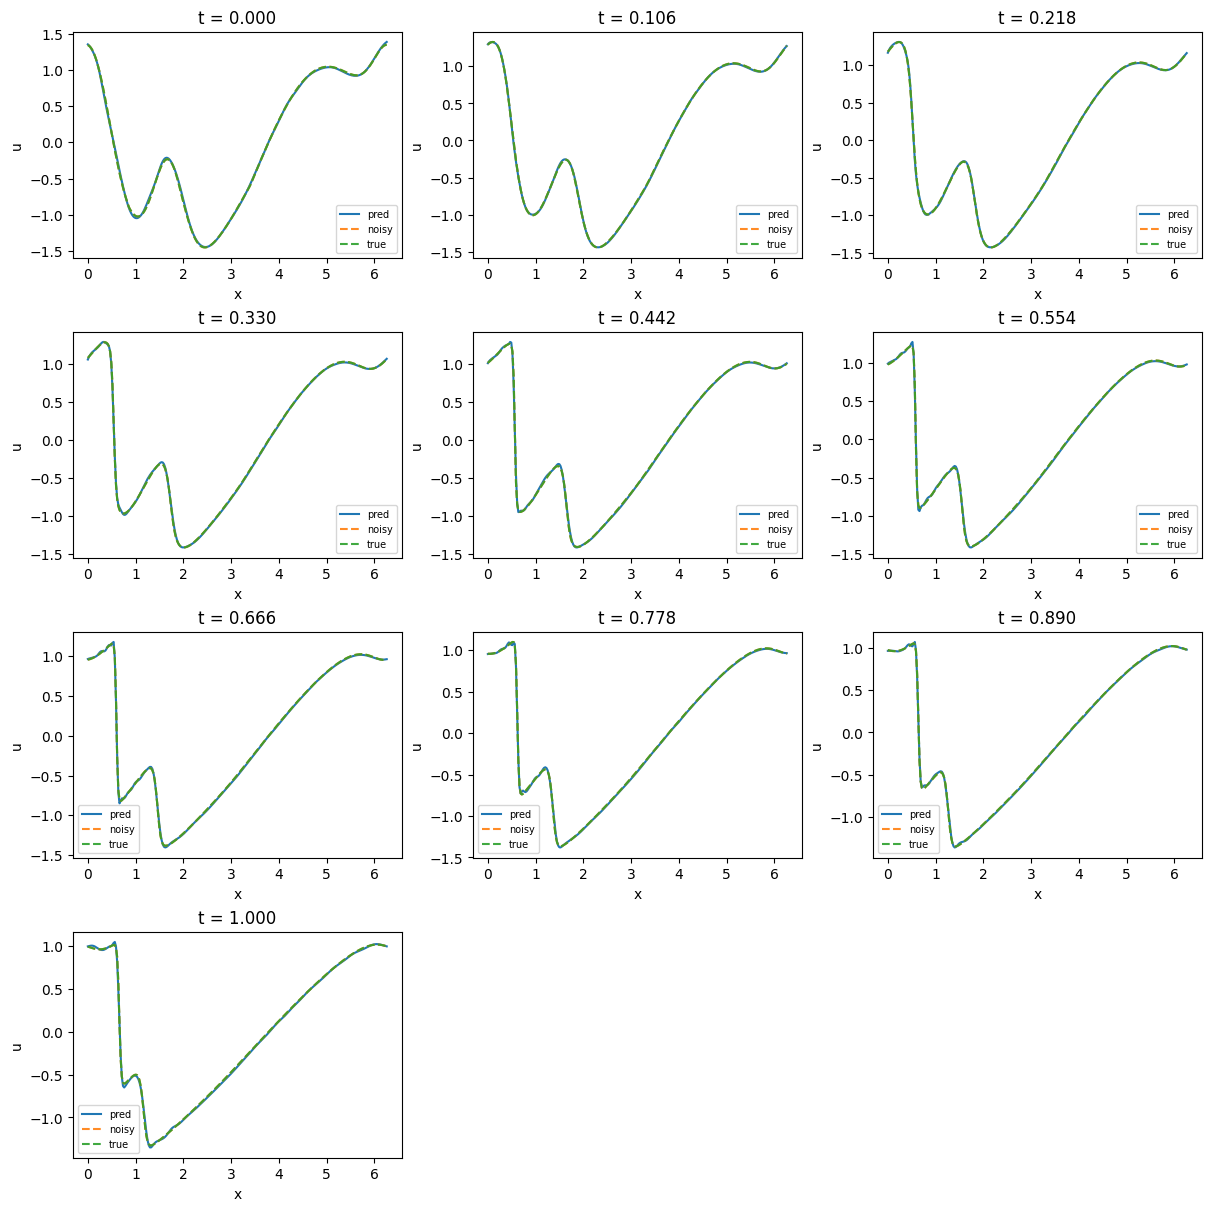

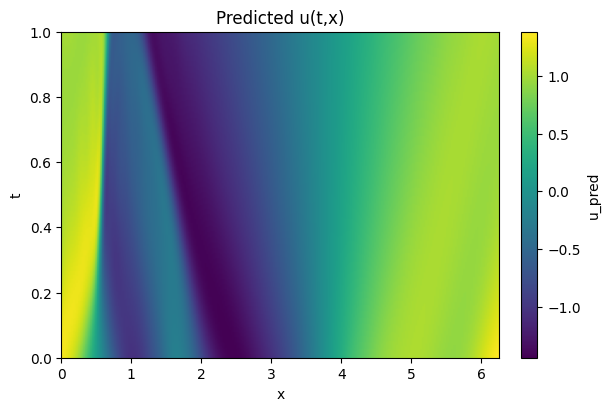

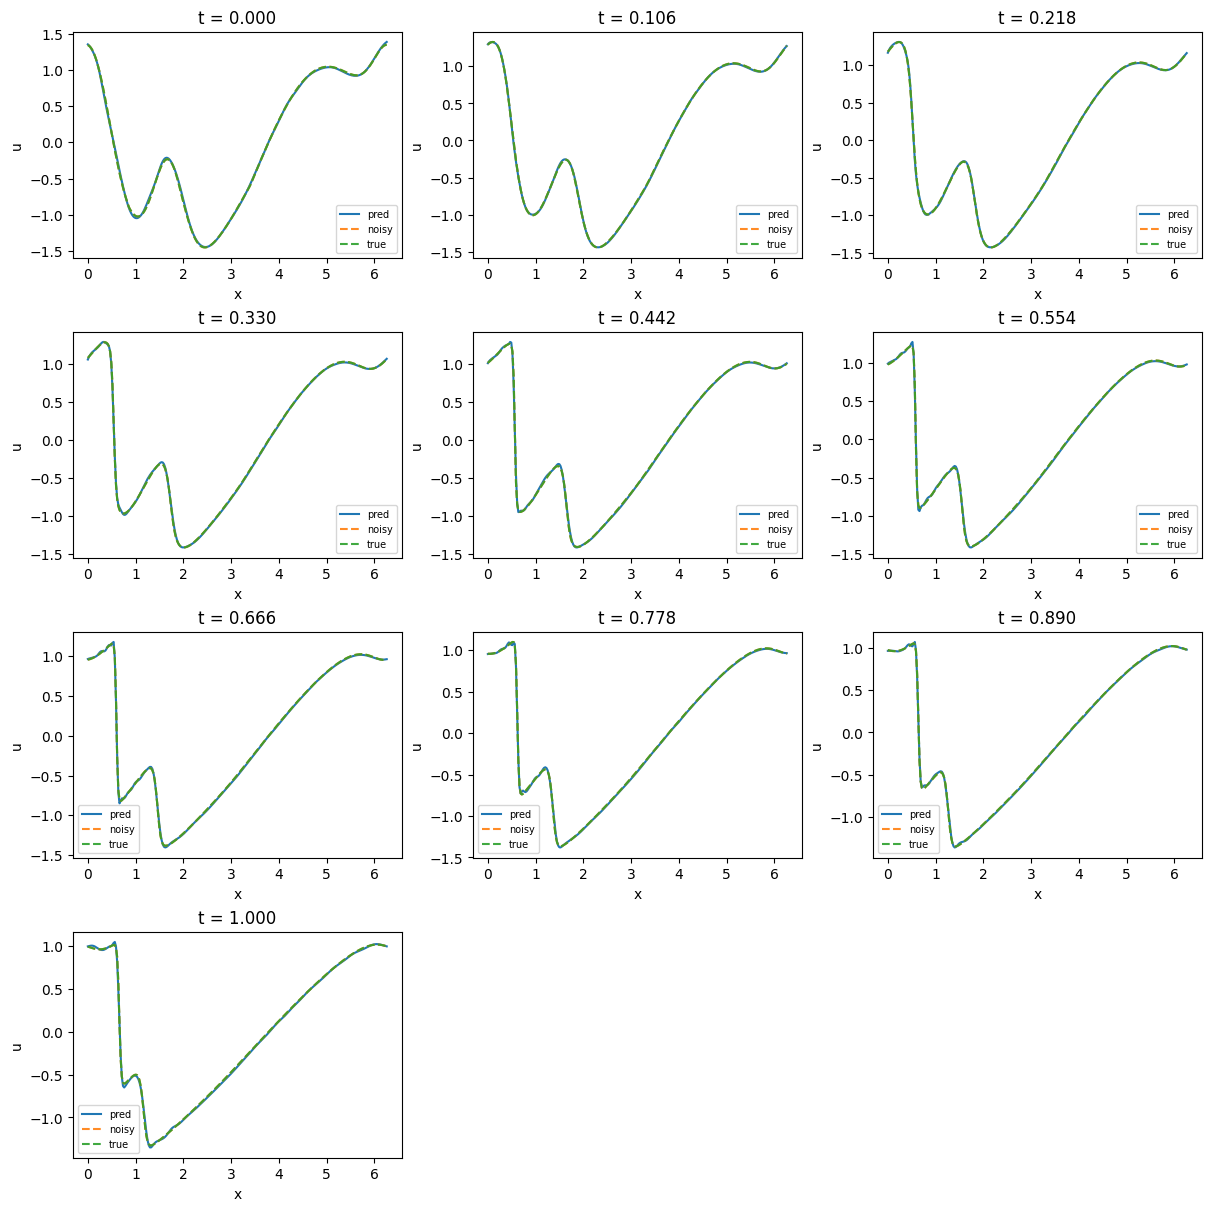

In [ ]:
# Verify data fit with plots (N4BL4)
snapshot_comp(trainer.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[0]

In [ ]:
from scipy.linalg import lstsq

# Extract u_t and F from trainer
u_t = trainer.u_t.detach().cpu().numpy().flatten()
F_cop = trainer.F.detach().cpu().numpy()
uu_x = F_cop[:,0]*F_cop[:,1]
F_cop[:,0] = uu_x

# Solve least squares: min ||u_t - F @ w||^2
w_ls, residuals, rank, s = lstsq(F_cop, u_t)



In [ ]:
print("Least squares solution:")
print(f"w = {w_ls}")
print(f"Residuals: {residuals}")
print(f"Rank: {rank}")

['u', 'u_x', 'u_xx']
Least squares solution:
w = [-0.806721   -0.049701    0.02188494]
Residuals: 212.74176025390625
Rank: 3


In [ ]:
symnet = EQL(in_dim=3, prod_dim=2, bias=False)
symnet.linear.weight
with torch.no_grad():
    symnet.linear.weight.copy_(torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], dtype=symnet.linear.weight.dtype, device=symnet.linear.weight.device))
    symnet.readout.weight.copy_(torch.tensor([[0.0, -0.046737, 0.0225, -0.8540]], dtype=symnet.readout.weight.dtype, device=symnet.readout.weight.device))
print("symnet readout weights:")
print(symnet.readout.weight, '\n')

symnet readout weights:
Parameter containing:
tensor([[ 0.0000, -0.0467,  0.0225, -0.8540]], requires_grad=True) 



In [ ]:
F = trainer.F
trainer.mse(symnet(F),trainer.u_t)

tensor(184.7495, grad_fn=<MseLossBackward0>)

In [ ]:
import os
os.getcwd()
data_path = "../Datasets/burgers.mat"
print(f"Data loaded from {data_path}")

Data loaded from ../Datasets/burgers.mat
